Please note this file is not for listing different attacks that the system can detect
for that purpose u can refere to the attack folder in the root directory

this file is to measure and evaulte different system property on attacks that is known that the system can detect successfully 

In [14]:
#testing the kernel is working
print("hello world")

hello world


In [4]:
# install packages
%pip install nats-py aiohttp matplotlib numpy

  Using cached nats_py-2.15.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.3 kB)
  Using cached propcache-0.5.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached yarl-1.24.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (94 kB)
Using cached nats_py-2.15.0-py3-none-any.whl (90 kB)
Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.8 MB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Usin

In [6]:


# this cell collect eracdication time data to measure it 


import asyncio
import time
import json
import aiohttp
import nats
import matplotlib.pyplot as plt
import numpy as np
from nats.errors import TimeoutError

# Configuration
NATS_URL = "nats://127.0.0.1:4222"
TARGET_URL = "http://127.0.0.1:8080/api/loans/export?id=%00" # Null-byte attack
TARGET_WORKLOAD = "frontend-ui"
ITERATIONS = 10

async def check_service_health():
    """Polls the frontend until it is back online after a pod cycle."""
    health_url = "http://127.0.0.1:8080/"
    while True:
        try:
            async with aiohttp.ClientSession() as session:
                async with session.get(health_url, timeout=1) as resp:
                    if resp.status == 200:
                        return
        except Exception:
            pass
        await asyncio.sleep(1)

async def measure_eradication_time(iterations):
    nc = await nats.connect(NATS_URL)
    remediation_times = []
    
    print(f"Starting {iterations} eradication measurement iterations...")
    
    for i in range(iterations):
        print(f"Iteration {i+1}/{iterations} ")
        
     
        await check_service_health()
        print("Target is healthy. Launching attack...")
        
        start_time = time.time()
        remediation_event = asyncio.Event()
        
        
        async def message_handler(msg):
            remediation_event.set()
            
        sub = await nc.subscribe(f"auranet.remediated.{TARGET_WORKLOAD}", cb=message_handler)
        
       
        try:
            async with aiohttp.ClientSession() as session:
                # The request will likely drop when the quarantine network policy is applied
                await session.get(TARGET_URL, timeout=2)
        except Exception:
            pass 
            
        
        try:
            # Timeout set slightly higher than the AutoHeal 5s propagation delay
            await asyncio.wait_for(remediation_event.wait(), timeout=15.0)
            end_time = time.time()
            
            delta = end_time - start_time
            remediation_times.append(delta)
            print(f"Eradication confirmed in {delta:.2f} seconds.")
            
        except asyncio.TimeoutError:
            print("ERROR: Remediation signal timed out.")
            
        await sub.unsubscribe()
        await asyncio.sleep(2) # Brief cooldown buffer

    await nc.close()
    return remediation_times

# Jupyter automatically manages the asyncio event loop
# We can await the function directly in the cell
eradication_data = await measure_eradication_time(ITERATIONS)

Starting 10 eradication measurement iterations...
Iteration 1/10 
Target is healthy. Launching attack...


Eradication confirmed in 10.03 seconds.
Iteration 2/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 3/10 
Target is healthy. Launching attack...
Eradication confirmed in 7.83 seconds.
Iteration 4/10 
Target is healthy. Launching attack...
Eradication confirmed in 10.00 seconds.
Iteration 5/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 6/10 
Target is healthy. Launching attack...
Eradication confirmed in 7.82 seconds.
Iteration 7/10 
Target is healthy. Launching attack...
Eradication confirmed in 8.07 seconds.
Iteration 8/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 9/10 
Target is healthy. Launching attack...
ERROR: Remediation signal timed out.
Iteration 10/10 
Target is healthy. Launching attack...
Eradication confirmed in 8.81 seconds.


In [10]:
print(eradication_data)
print(len(eradication_data))

[10.027106761932373, 7.8262739181518555, 10.002405881881714, 7.823514938354492, 8.072347640991211, 8.814457654953003]
6


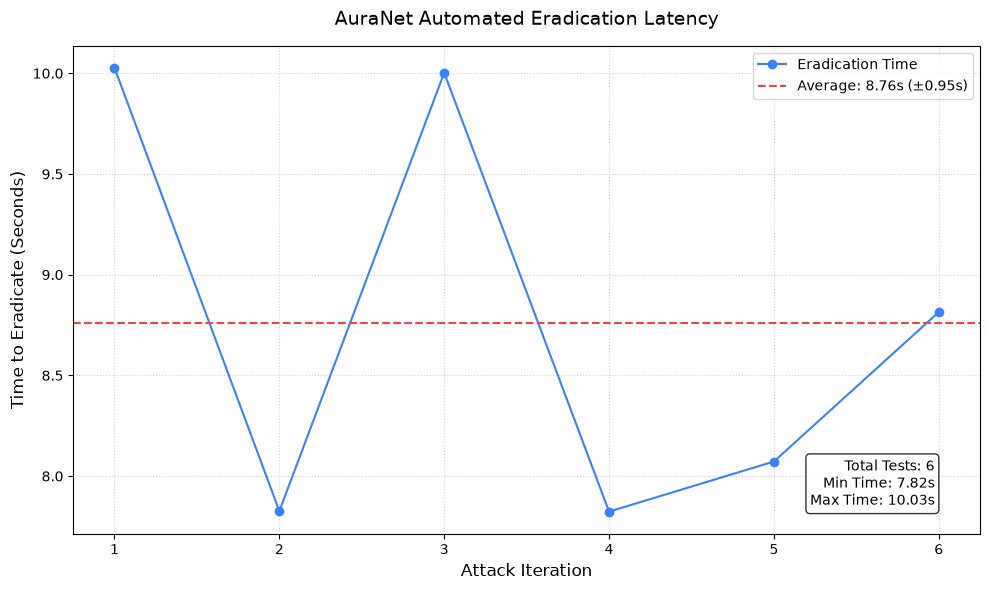

In [11]:
#plotting eradication time

def plot_eradication_metrics(data):
    if not data:
        print("No data collected to plot.")
        return
        
    iterations = np.arange(1, len(data) + 1)
    average_time = np.mean(data)
    std_dev = np.std(data)
    
    plt.figure(figsize=(10, 6))
    
    # Plot individual iteration times
    plt.plot(iterations, data, marker='o', linestyle='-', color='#3b82f6', label='Eradication Time')
    
    # Plot the average line
    plt.axhline(y=average_time, color='#ef4444', linestyle='--', 
                label=f'Average: {average_time:.2f}s (±{std_dev:.2f}s)')
    
    plt.title('AuraNet Automated Eradication Latency', fontsize=14, pad=15)
    plt.xlabel('Attack Iteration', fontsize=12)
    plt.ylabel('Time to Eradicate (Seconds)', fontsize=12)
    
    plt.xticks(iterations)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Add a text box with statistics
    stats_text = (
        f"Total Tests: {len(data)}\n"
        f"Min Time: {np.min(data):.2f}s\n"
        f"Max Time: {np.max(data):.2f}s"
    )
    plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_eradication_metrics(eradication_data)

In [12]:
# the average of the eradication time is 8.7 
print(sum(eradication_data)/len(eradication_data))

8.761017799377441


an average of 8.7 is extrememly good thus proving that the system can be deployed in some critical infrastructure